# Analyze Diabetes Data

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv")

In [6]:
df

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [8]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [9]:
df.shape

(101766, 50)

In [10]:
df.dtypes

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

In [13]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


# Cleaning Tasks

In [28]:
missing_data = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing Percentage": (
        df.isna().mean() * 100
    ).round(2)
})

missing_data = missing_data.sort_values(
    "Missing Values",
    ascending=False
)

missing_data

,Missing Values,Missing Percentage
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02
encounter_id,0,0.00


In [40]:
df.replace("?", np.nan, inplace=True)
df_clean = df[df["gender"] != "Unknown/Invalid"].copy()
df_clean = df[df["race"] != "Unknown/Invalid"].copy()
df_clean["time_in_hospital"] = pd.to_numeric(
    df_clean["time_in_hospital"], errors="coerce"
)

In [43]:
missing_data = pd.DataFrame({
    "Missing Values": df_clean.isna().sum(),
    "Missing Percentage": (
        df.isna().mean() * 100
    ).round(2)
})

missing_data = missing_data.sort_values(
    "Missing Values",
    ascending=False
)

missing_data

,Missing Values,Missing Percentage
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02
encounter_id,0,0.00


<Axes: >

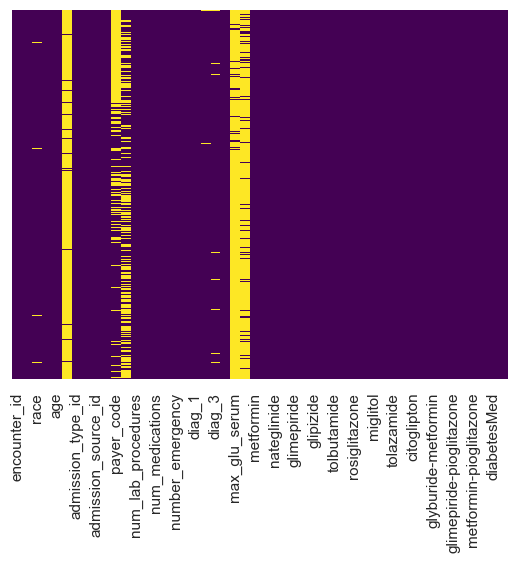

In [49]:
sns.heatmap(comparison_df.isnull(),yticklabels=False,cbar=False,cmap="viridis")

In [86]:
df.drop(columns=[ "A1Cresult", "weight", "payer_code"], inplace=True)

/var/folders/vb/8wr6j2gx0v9fld5yt1l8km380000gn/T/ipykernel_55014/3214495813.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='readmitted',y='age',data=df,palette='winter')


<Axes: xlabel='readmitted', ylabel='age'>

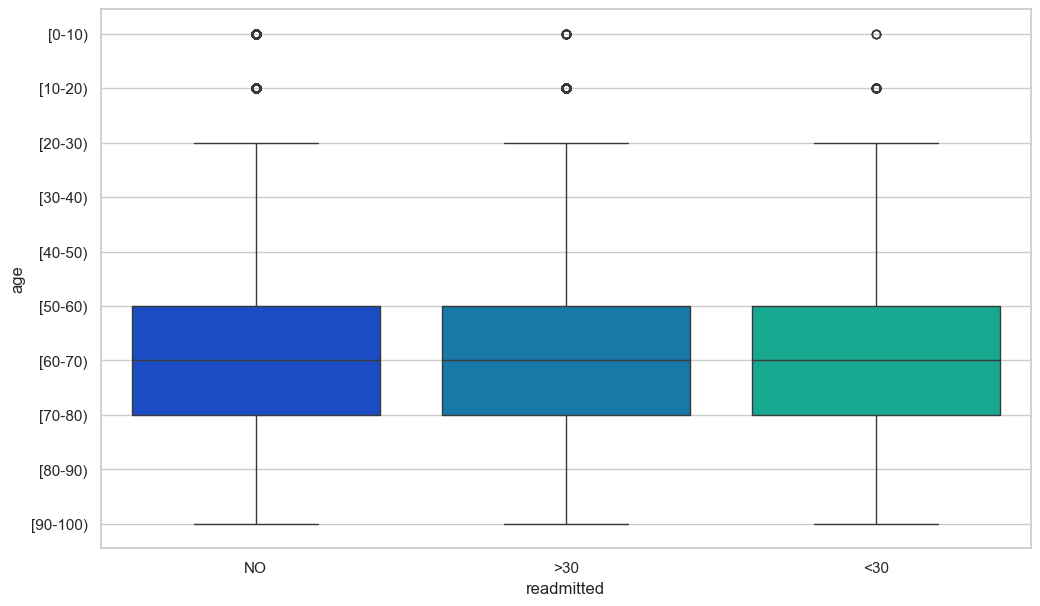

In [74]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='readmitted',y='age',data=df,palette='winter')

# Group Filtering

In [16]:
comparison_df = df_clean[df_clean["age"].isin(["[30-40)", "[70-80)"])]

# Visualization

/var/folders/vb/8wr6j2gx0v9fld5yt1l8km380000gn/T/ipykernel_55014/548945892.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


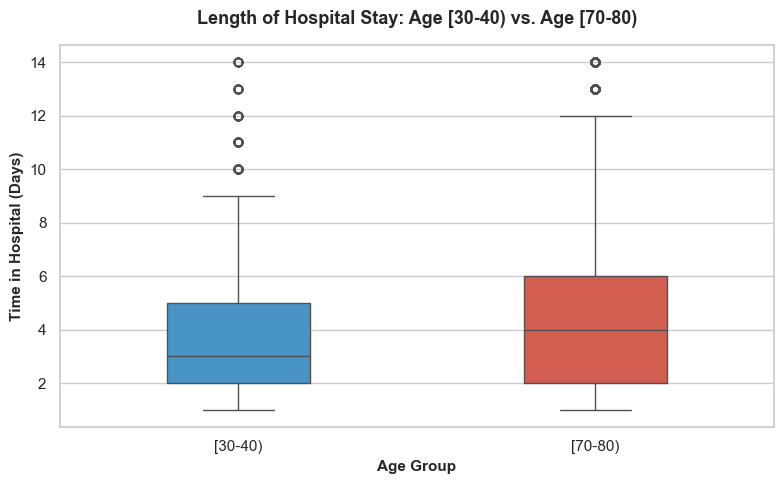

In [44]:
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(
    x="age",
    y="time_in_hospital",
    data=comparison_df,
    palette=["#3498db", "#e74c3c"],
    width=0.4,
)
plt.title(
    "Length of Hospital Stay: Age [30-40) vs. Age [70-80)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Age Group", fontsize=11, fontweight="bold")
plt.ylabel("Time in Hospital (Days)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

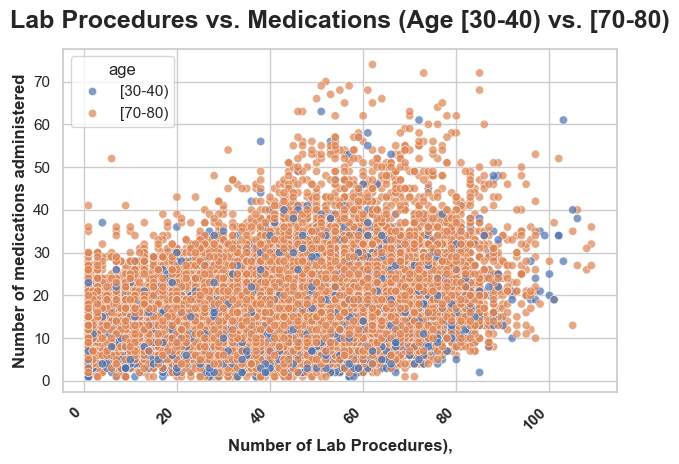

In [34]:
sns.scatterplot(
    data=comparison_df,
    x="num_lab_procedures",
    y="num_medications",
    hue="age",
    alpha=0.7
)
plt.xticks(rotation=45, ha="right", fontweight="bold")
plt.title("Lab Procedures vs. Medications (Age [30-40) vs. [70-80)",fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Number of Lab Procedures)"",", fontsize=12, fontweight="bold")
plt.ylabel("Number of medications administered", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

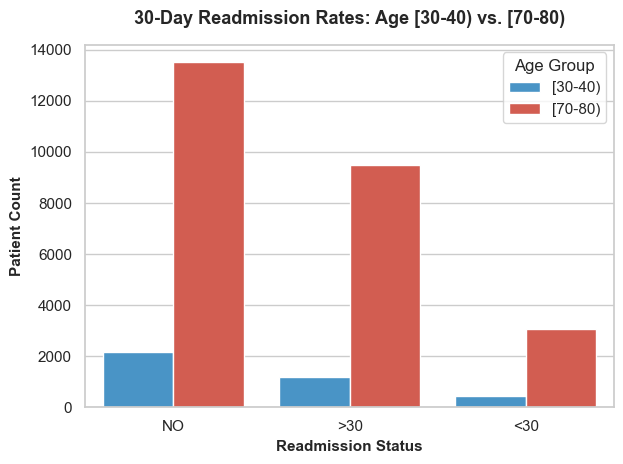

In [35]:
sns.countplot(
    data=comparison_df,
    x="readmitted",
    hue="age",
    palette=["#3498db", "#e74c3c"],
    order=["NO", ">30", "<30"],
)

plt.title(
    "30-Day Readmission Rates: Age [30-40) vs. [70-80)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Readmission Status", fontsize=11, fontweight="bold")
plt.ylabel("Patient Count", fontsize=11, fontweight="bold")
plt.legend(title="Age Group")
plt.tight_layout()
plt.show()

/var/folders/vb/8wr6j2gx0v9fld5yt1l8km380000gn/T/ipykernel_55014/2572599838.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


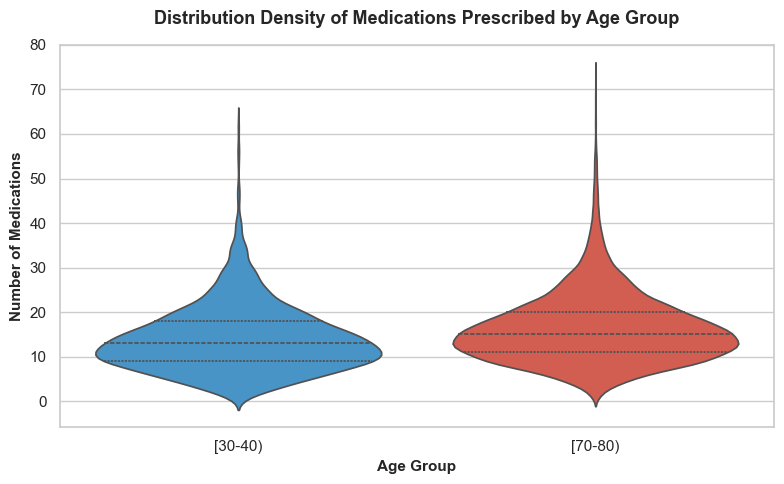

In [36]:
plt.figure(figsize=(8, 5))
sns.violinplot(
    data=comparison_df,
    x="age",
    y="num_medications",
    palette=["#3498db", "#e74c3c"],
    inner="quartile",
)

plt.title(
    "Distribution Density of Medications Prescribed by Age Group",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Age Group", fontsize=11, fontweight="bold")
plt.ylabel("Number of Medications", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

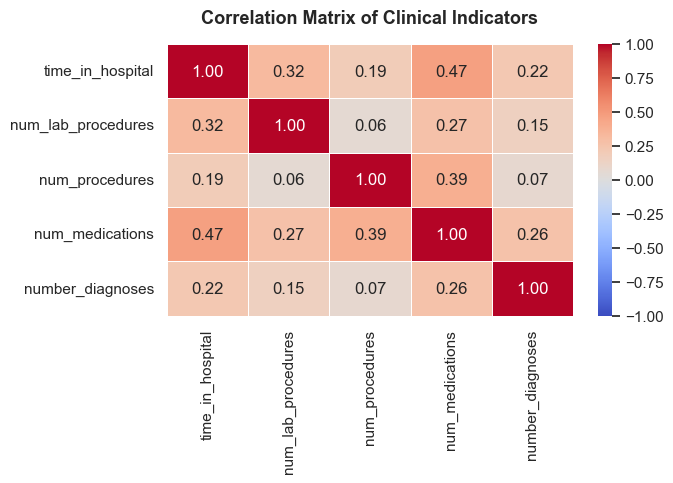

In [37]:
num_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_diagnoses",
]
corr = df_clean[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, linewidths=0.5
)
plt.title(
    "Correlation Matrix of Clinical Indicators",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()
plt.show()

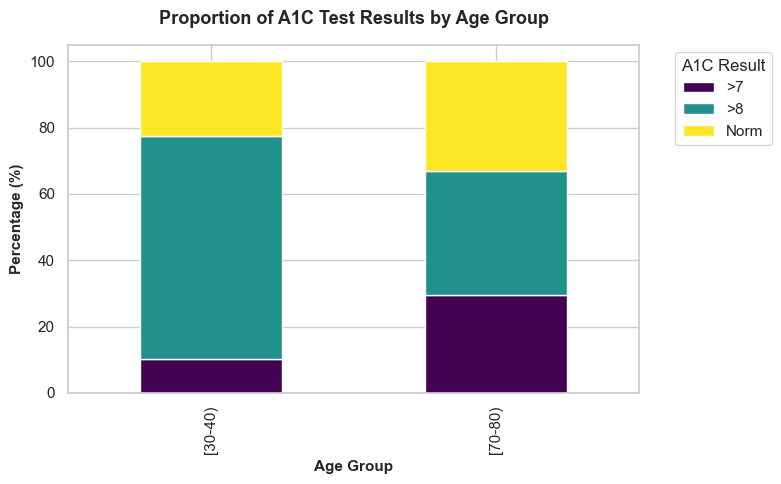

In [38]:
props = (
    pd.crosstab(
        comparison_df["age"], comparison_df["A1Cresult"], normalize="index"
    )
    * 100
)

ax = props.plot(kind="bar", stacked=True, figsize=(8, 5), colormap="viridis")
plt.title(
    "Proportion of A1C Test Results by Age Group",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Age Group", fontsize=11, fontweight="bold")
plt.ylabel("Percentage (%)", fontsize=11, fontweight="bold")
plt.legend(title="A1C Result", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

/var/folders/vb/8wr6j2gx0v9fld5yt1l8km380000gn/T/ipykernel_55014/2259428276.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='time_in_hospital', data=comparison_df,palette='RdBu_r')


<Axes: xlabel='time_in_hospital', ylabel='count'>

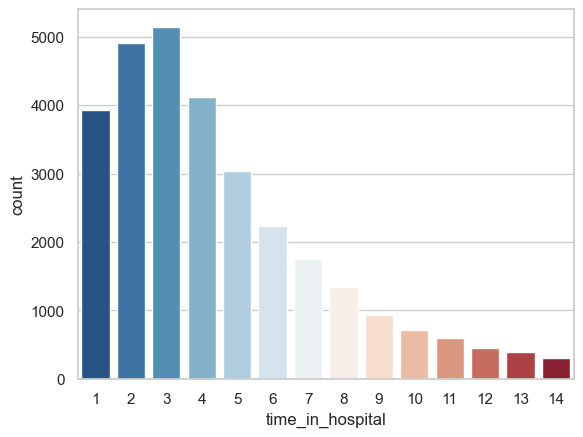

In [55]:
sns.set_style('whitegrid')
sns.countplot(x='time_in_hospital', data=comparison_df,palette='RdBu_r')

<Axes: xlabel='time_in_hospital', ylabel='count'>

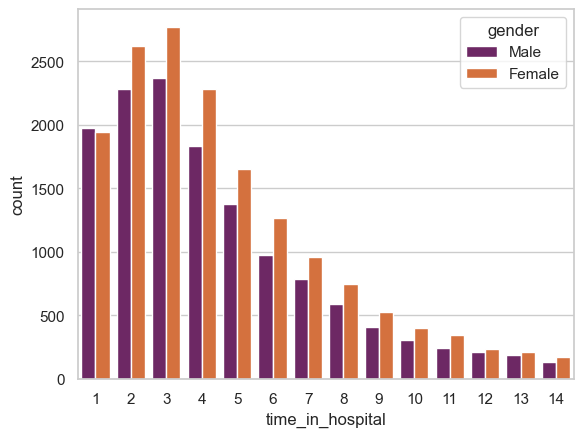

In [59]:
sns.set_style('whitegrid')
sns.countplot(x='time_in_hospital',hue='gender', data=comparison_df,palette='inferno')

<Figure size 1400x1200 with 0 Axes>

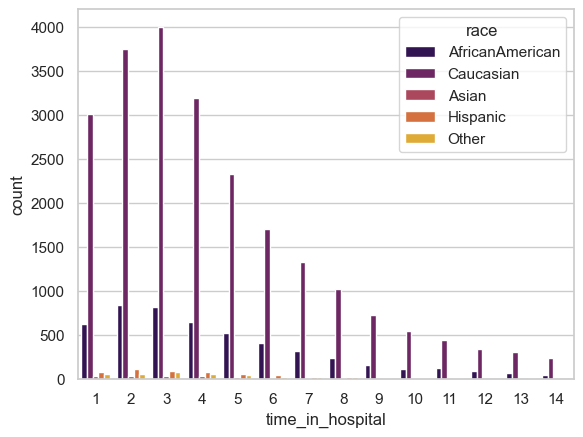

<Figure size 1400x1200 with 0 Axes>

In [63]:
sns.set_style('whitegrid')
sns.countplot(x='time_in_hospital',hue='race', data=comparison_df,palette='inferno')
plt.figure(figsize=(14, 12))

<Axes: xlabel='age', ylabel='Count'>

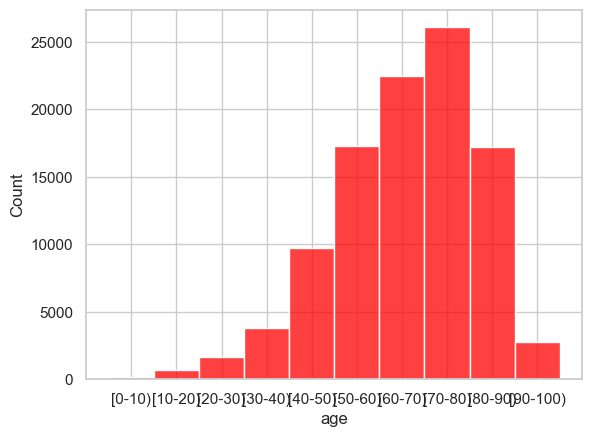

In [71]:
sns.histplot(df['age'].dropna(),kde=False,color="red",bins=40)

<Axes: xlabel='race', ylabel='count'>

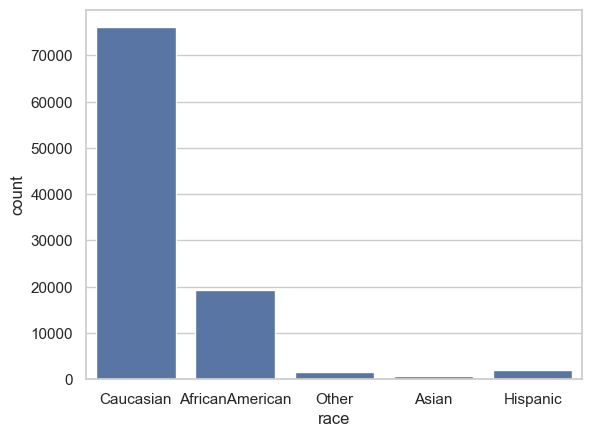

In [89]:
sns.countplot(x='race', data=df)

In [117]:
## train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df.drop('num_medications', axis=1), df['num_medications'], test_size=0.30, random_state=101)

In [130]:
from sklearn.linear_model import LogisticRegression

In [123]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=101,
    stratify=y
)

logmodel = LogisticRegression(max_iter=1000)
logmodel.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [127]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Remove observations with missing outcomes
model_df = df.dropna(subset=["gender"]).copy()

# 2. Separate predictors and outcome
X = model_df.drop("gender", axis=1)
y = model_df["gender"]

# 3. Convert categorical predictors to dummy variables
X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

# 4. Address any remaining missing values
X = X.fillna(X.median(numeric_only=True))
X = X.fillna(0)

# 5. Split the encoded data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=101,
    stratify=y
)

# 6. Fit a new model using these exact columns
logmodel = LogisticRegression(max_iter=2000)
logmodel.fit(X_train, y_train)

# 7. Predict using the matching test columns
predictions = logmodel.predict(X_test)

Accuracy: 0.538

Confusion Matrix:
[[16412     0     0]
 [14117     0     0]
 [    1     0     0]]

Classification Report:


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                 precision    recall  f1-score   support

         Female       0.54      1.00      0.70     16412
           Male       0.00      0.00      0.00     14117
Unknown/Invalid       0.00      0.00      0.00         1

       accuracy                           0.54     30530
      macro avg       0.18      0.33      0.23     30530
   weighted avg       0.29      0.54      0.38     30530



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


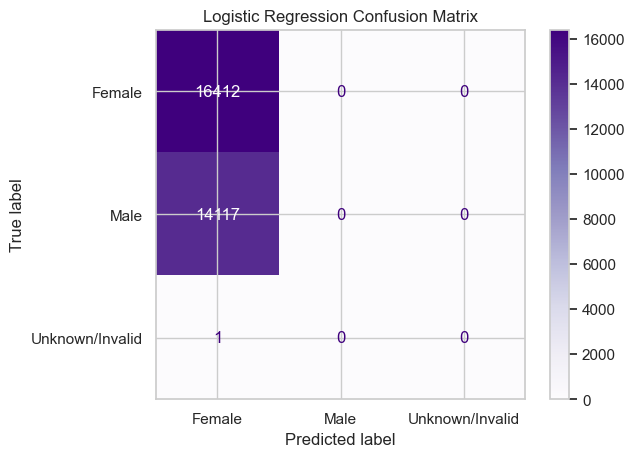

In [128]:
accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy: {accuracy:.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    cmap="Purples"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [129]:
print(X_train.shape)
print(X_test.shape)
print(X_train.columns.equals(X_test.columns))

(71236, 2399)
(30530, 2399)
True
